In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [3]:
# loading dataset

df = pd.read_csv("student.csv")

# first 5 rows

print(df.head())

# dataset information

print(df.shape)

print(df.dtypes)

print(df.isnull().sum())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
(1000, 8)
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
t

In [4]:
# creating pass/fail column

df['pass_fail'] = np.where(df['math score'] >= 40, 1, 0)

# encoding categorical columns

le = LabelEncoder()

for column in df.columns:
    
    if df[column].dtype == 'object' or df[column].dtype == 'str':
        
        df[column] = le.fit_transform(df[column])

# checking first 5 rows

print(df.head())

   gender  race/ethnicity  parental level of education  lunch  \
0       0               1                            1      1   
1       0               2                            4      1   
2       0               1                            3      1   
3       1               0                            0      0   
4       1               2                            4      1   

   test preparation course  math score  reading score  writing score  \
0                        1          72             72             74   
1                        0          69             90             88   
2                        1          90             95             93   
3                        1          47             57             44   
4                        1          76             78             75   

   pass_fail  
0          1  
1          1  
2          1  
3          1  
4          1  


In [5]:
# selecting regression input and target

X_reg = df.drop(['math score', 'pass_fail'], axis=1)

y_reg = df['math score']

# feature scaling

scaler = StandardScaler()

X_reg_scaled = scaler.fit_transform(X_reg)

# train-test split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_scaled,
    y_reg,
    test_size=0.2,
    random_state=42
)

# checking shapes

print(X_train_reg.shape)

print(X_test_reg.shape)

(800, 7)
(200, 7)


In [6]:
# linear regression model

lr = LinearRegression()

# training model

lr.fit(X_train_reg, y_train_reg)

# predictions

y_pred_lr = lr.predict(X_test_reg)

# evaluation

mae = mean_absolute_error(y_test_reg, y_pred_lr)

rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))

r2 = r2_score(y_test_reg, y_pred_lr)

print("Linear Regression Results")

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

Linear Regression Results
MAE: 4.130145078004059
RMSE: 5.317450940660138
R2 Score: 0.8838026201112221


In [7]:
# random forest regressor

rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# training model

rf_reg.fit(X_train_reg, y_train_reg)

# predictions

y_pred_rf_reg = rf_reg.predict(X_test_reg)

# evaluation

mae_rf = mean_absolute_error(y_test_reg, y_pred_rf_reg)

rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))

r2_rf = r2_score(y_test_reg, y_pred_rf_reg)

print("Random Forest Regression Results")

print("MAE:", mae_rf)

print("RMSE:", rmse_rf)

print("R2 Score:", r2_rf)

Random Forest Regression Results
MAE: 4.713573809523809
RMSE: 6.063696250599092
R2 Score: 0.8489000822741931


In [8]:
# selecting classification input and target

X_clf = df.drop(['math score', 'pass_fail'], axis=1)

y_clf = df['pass_fail']

# feature scaling

X_clf_scaled = scaler.fit_transform(X_clf)

# train-test split

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_scaled,
    y_clf,
    test_size=0.2,
    random_state=42
)

# checking shapes

print(X_train_clf.shape)

print(X_test_clf.shape)

(800, 7)
(200, 7)


In [9]:
# logistic regression classifier

lr_clf = LogisticRegression()

# training model

lr_clf.fit(X_train_clf, y_train_clf)

# predictions

y_pred_lr_clf = lr_clf.predict(X_test_clf)

# evaluation

print("Logistic Regression Classification Results")

print("Accuracy:",
      accuracy_score(y_test_clf, y_pred_lr_clf))

print("Precision:",
      precision_score(y_test_clf, y_pred_lr_clf))

print("Recall:",
      recall_score(y_test_clf, y_pred_lr_clf))

print("F1 Score:",
      f1_score(y_test_clf, y_pred_lr_clf))

Logistic Regression Classification Results
Accuracy: 0.995
Precision: 0.9947368421052631
Recall: 1.0
F1 Score: 0.9973614775725593


In [10]:
# random forest classifier

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# training model

rf_clf.fit(X_train_clf, y_train_clf)

# predictions

y_pred_rf_clf = rf_clf.predict(X_test_clf)

# evaluation

print("Random Forest Classification Results")

print("Accuracy:",
      accuracy_score(y_test_clf, y_pred_rf_clf))

print("Precision:",
      precision_score(y_test_clf, y_pred_rf_clf))

print("Recall:",
      recall_score(y_test_clf, y_pred_rf_clf))

print("F1 Score:",
      f1_score(y_test_clf, y_pred_rf_clf))

Random Forest Classification Results
Accuracy: 0.985
Precision: 0.984375
Recall: 1.0
F1 Score: 0.9921259842519685


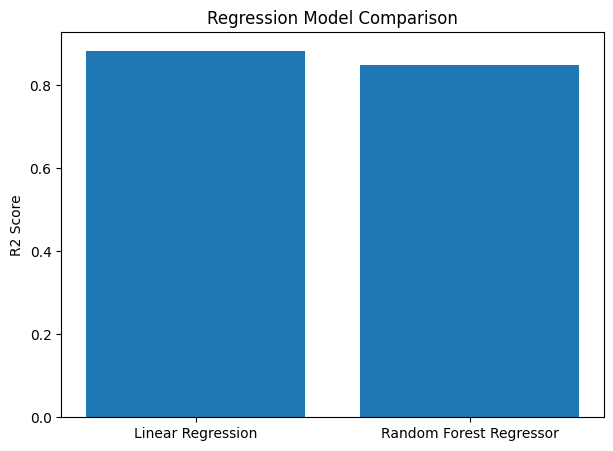

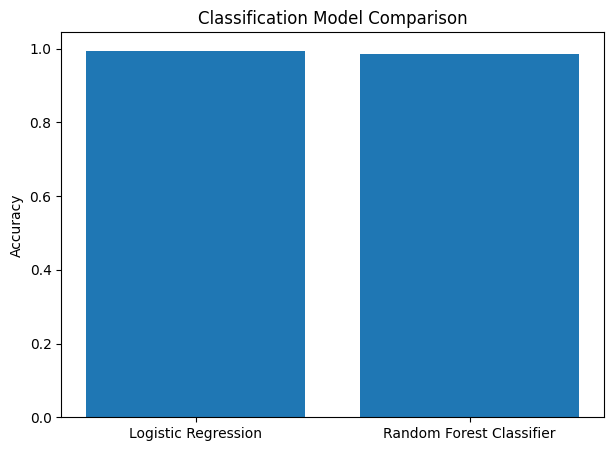

In [11]:
# regression model comparison

reg_models = [
    'Linear Regression',
    'Random Forest Regressor'
]

reg_scores = [
    r2,
    r2_rf
]

plt.figure(figsize=(7,5))

plt.bar(reg_models, reg_scores)

plt.title("Regression Model Comparison")

plt.ylabel("R2 Score")

plt.show()

# classification model comparison

clf_models = [
    'Logistic Regression',
    'Random Forest Classifier'
]

clf_scores = [
    accuracy_score(y_test_clf, y_pred_lr_clf),
    accuracy_score(y_test_clf, y_pred_rf_clf)
]

plt.figure(figsize=(7,5))

plt.bar(clf_models, clf_scores)

plt.title("Classification Model Comparison")

plt.ylabel("Accuracy")

plt.show()

# Conclusion

In this project, student performance prediction was performed using both regression and classification machine learning models.

First, a new feature called pass/fail was created based on the math score. Students scoring 40 or above were marked as pass, while others were marked as fail.

For the regression task, the models predicted math scores:

* Linear Regression
* Random Forest Regressor

Among them, Linear Regression achieved the best performance with the highest R2 score.

For the classification task, the models predicted pass/fail status:

* Logistic Regression
* Random Forest Classifier

Logistic Regression achieved the highest classification accuracy and F1 score.

This project helped in understanding:

* feature engineering
* regression models
* classification models
* feature scaling
* model evaluation
* comparison of machine learning algorithms

The project also demonstrated how machine learning can be used in educational performance prediction systems.
